In [1]:
import pandas as pd
expression = pd.read_csv("TCGA.STAD.expression.txt", sep="\t", index_col=0)
metadata = pd.read_csv("TCGA.STAD.metadata.txt", sep="\t")
mutation = pd.read_csv("TCGA.STAD.mutations.txt", sep="\t")

In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt


In [15]:
expr = pd.read_csv("TCGA.STAD.expression.txt", sep='\t', index_col=0).T
mut = pd.read_csv("TCGA.STAD.mutations.txt", sep='\t', index_col=0).T
meta = pd.read_csv("TCGA.STAD.metadata.txt", sep='\t')

# Check first few lines
print("expr raw shape:", expr.shape)
print("mut raw shape:", mut.shape)
print("meta raw shape:", meta.shape)


expr raw shape: (20532, 447)
mut raw shape: (52, 234941)
meta raw shape: (415, 19)


In [37]:
import pandas as pd

# --- Load raw data ---
expr_raw = expr.copy()
mut_raw = mut.copy()

# --- Fix Expression ---
expr_fixed = expr_raw.copy()
expr_fixed.columns = expr_fixed.iloc[0]  # set column names to SAMPLE_ID row
expr_fixed = expr_fixed.iloc[2:, :]      # remove SAMPLE_ID and gene ID rows
expr_fixed = expr_fixed.T                # transpose

expr_fixed.index = expr_fixed.index.astype(str)
expr_fixed = expr_fixed[expr_fixed.index.str.startswith("TCGA")]
expr_fixed.index = expr_fixed.index.str.slice(0, 12)  # get patient IDs
expr_fixed = expr_fixed.apply(pd.to_numeric, errors='coerce')
expr_fixed = expr_fixed.loc[~expr_fixed.index.duplicated()]
expr_fixed = expr_fixed.dropna(axis=1, how="any")  # optional

# --- Fix Mutation ---
mut_fixed = mut_raw.copy()

mut_fixed = mut_fixed.T
mut_fixed.index = mut_fixed.index.astype(str)
mut_fixed = mut_fixed[mut_fixed.index.str.startswith("TCGA")]
mut_fixed.index = mut_fixed.index.str.slice(0, 12)
mut_fixed = mut_fixed.loc[~mut_fixed.index.duplicated()]

# Only keep numeric mutation values, binarize
mut_bin = mut_fixed.apply(pd.to_numeric, errors='coerce')
mut_bin = (mut_bin > 0).astype(int)
mut_bin = mut_bin.loc[:, ~mut_bin.columns.duplicated()]

# --- Intersect patients ---
shared_ids = expr_fixed.index.intersection(mut_bin.index)
expr_shared = expr_fixed.loc[shared_ids]
mut_shared = mut_bin.loc[shared_ids]

# --- Select top 1000 variable genes ---
expr_var = expr_shared.var().sort_values(ascending=False)
expr_top = expr_shared[expr_var.index[:1000]]

# --- Combine feature matrix ---
X = pd.concat([expr_top, mut_shared], axis=1)
print("✅ Final combined feature matrix shape:", X.shape)
print("🔹 Shared patients used:", len(shared_ids))


✅ Final combined feature matrix shape: (415, 1048)
🔹 Shared patients used: 415


In [47]:
# --- Load and prepare metadata ---
meta_raw = pd.read_csv("TCGA.STAD.metadata.txt", sep="\t")
meta_raw = meta_raw.set_index("patient_id")
meta_raw = meta_raw.loc[~meta_raw.index.duplicated()]

# --- Align metadata with feature matrix ---
meta_aligned = meta_raw.loc[shared_ids]
print("✅ Metadata shape after alignment:", meta_aligned.shape)

# --- Final combined matrix with metadata ---
X_final = X.join(meta_aligned)
print("✅ Final shape with metadata:", X_final.shape)


✅ Metadata shape after alignment: (415, 18)
✅ Final shape with metadata: (415, 1066)


In [48]:
# --- Load and prepare metadata ---
meta_raw = pd.read_csv("TCGA.STAD.metadata.txt", sep="\t")
meta_raw = meta_raw.set_index("patient_id")
meta_raw = meta_raw.loc[~meta_raw.index.duplicated()]

# --- Align metadata with feature matrix ---
meta_aligned = meta_raw.loc[shared_ids]
print("✅ Metadata shape after alignment:", meta_aligned.shape)

# --- Final combined matrix with metadata ---
X_final = X.join(meta_aligned)
print("✅ Final shape with metadata:", X_final.shape)


✅ Metadata shape after alignment: (415, 18)
✅ Final shape with metadata: (415, 1066)


In [49]:
# Display the first 5 rows of the final dataset
print(X_final.head())


                ADAM6|8755       PGC|5225       LYZ|4069    OLFM4|10562  \
TCGA-CG-4460  4.768580e+04  362416.000000   28580.400000     462.772000   
TCGA-CG-5716  1.245320e+06  562113.000000   32518.600000   38653.800000   
TCGA-HF-7131  6.298700e+04   51842.200000  116325.000000  119339.000000   
TCGA-3M-AB46  1.942044e+03     283.718969   63273.558978  135309.666366   
TCGA-3M-AB47  1.673619e+05     231.114500    2538.765372     647.698468   

              KRT13|3860    CEL|1056    PGA3|643834   COL1A1|1277  \
TCGA-CG-4460  139.037000  135.747000  169603.000000  14432.700000   
TCGA-CG-5716   43.042900   11.563800   22649.200000  14093.000000   
TCGA-HF-7131   18.810400    1.393400     266.481000  31825.800000   
TCGA-3M-AB46    1.368493  220.724368       0.294594  79429.196260   
TCGA-3M-AB47    0.215859  303.123011      18.572194  99299.294171   

               LOC96610|966     DES|1674  ...  vital_status   OS  OS.time  \
TCGA-CG-4460   49972.600000  1716.580000  ...          De

In [50]:
# Split final matrix
numeric_cols = X_final.select_dtypes(include=['float', 'int']).columns
categorical_cols = X_final.select_dtypes(include=['object', 'category', 'bool']).columns


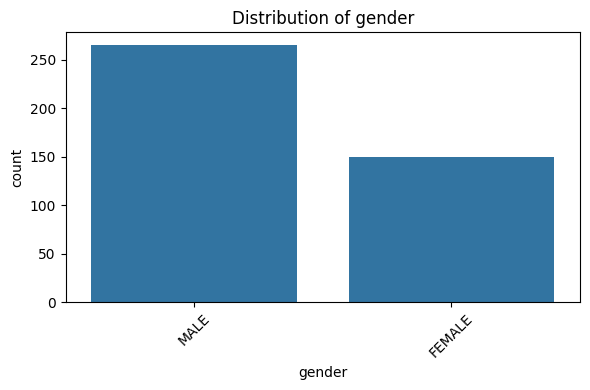

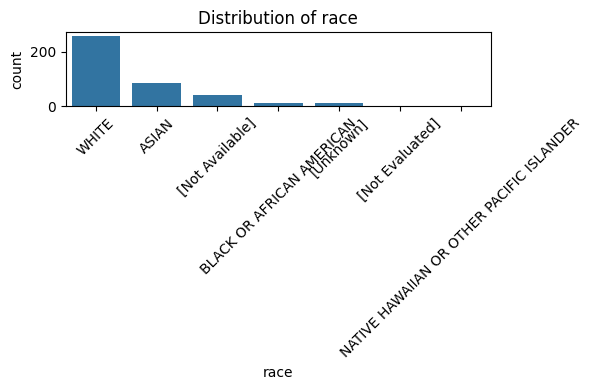

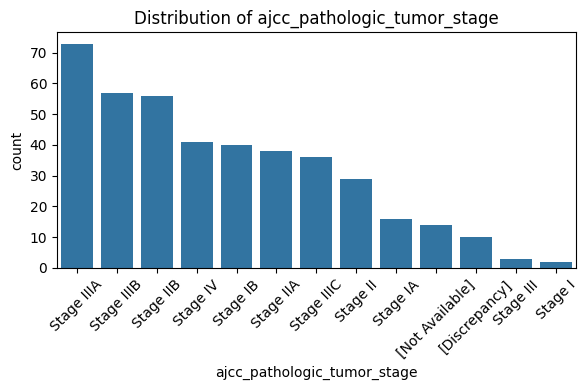

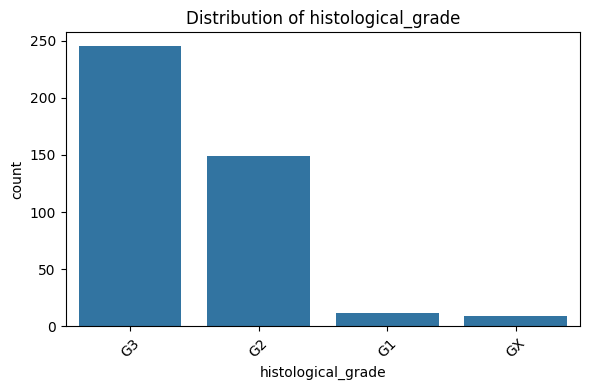

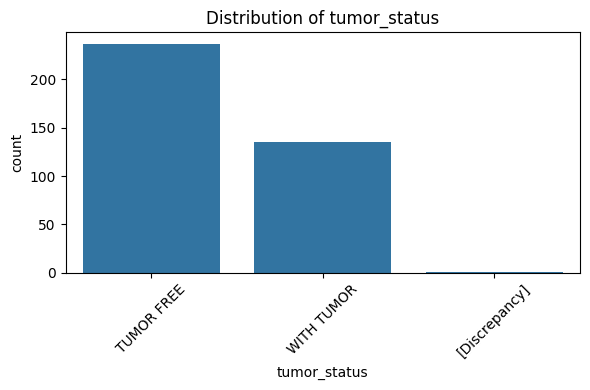

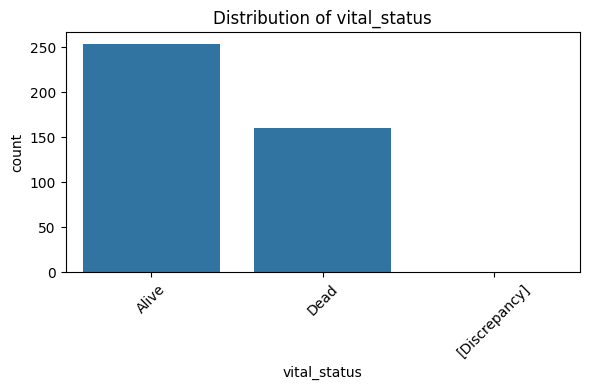

              mutation_burden  is_hypermutator  TP53_mutated  ARID1A_mutated  \
TCGA-CG-4460             77.0                0             0               0   
TCGA-CG-5716             97.0                1             0               0   
TCGA-HF-7131             11.0                0             0               0   
TCGA-3M-AB46             81.0                0             0               0   
TCGA-3M-AB47             62.0                0             0               0   

              CDH1_mutated  PIK3CA_mutated  KRAS_mutated  SMAD4_mutated  \
TCGA-CG-4460             0               0             0              0   
TCGA-CG-5716             0               0             0              0   
TCGA-HF-7131             0               0             0              0   
TCGA-3M-AB46             0               0             0              0   
TCGA-3M-AB47             0               0             0              0   

              PTEN_mutated  ERBB2_mutated  RHOA_mutated  RNF43_mutat

/var/folders/7s/vcvt681x3bn3b33blcfj30zr0000gn/T/ipykernel_60645/2315432630.py:18: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  X_final['mutation_burden'] = X_final[mutation_cols].sum(axis=1)


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot categorical metadata histograms
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 
                    'histological_grade', 'tumor_status', 'vital_status']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=X_final, x=col, order=X_final[col].dropna().value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 2. Create hypermutator flag
mutation_cols = [col for col in X_final.columns if "|" not in col and col not in categorical_cols + ['OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']]
X_final['mutation_burden'] = X_final[mutation_cols].sum(axis=1)
hyper_thresh = X_final['mutation_burden'].quantile(0.95)
X_final['is_hypermutator'] = (X_final['mutation_burden'] > hyper_thresh).astype(int)

# 3. Add binary flags for STAD driver genes (presence of mutation)
stad_drivers = ['TP53', 'ARID1A', 'CDH1', 'PIK3CA', 'KRAS', 'SMAD4', 'PTEN', 'ERBB2', 'RHOA', 'RNF43']
for gene in stad_drivers:
    matching_cols = [col for col in mutation_cols if col.startswith(gene + "|")]
    X_final[f"{gene}_mutated"] = X_final[matching_cols].sum(axis=1).gt(0).astype(int) if matching_cols else 0

# Preview updated dataframe
print(X_final[['mutation_burden', 'is_hypermutator'] + [f"{g}_mutated" for g in stad_drivers]].head())


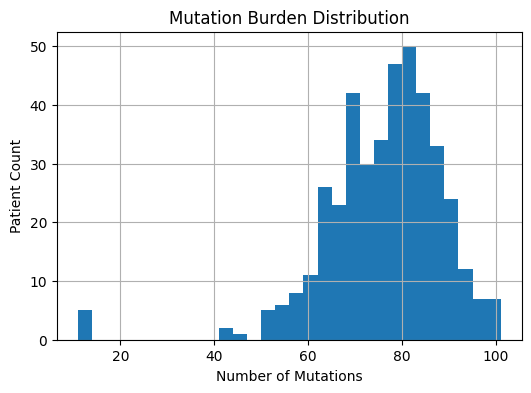

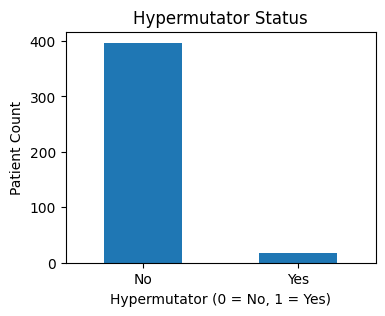

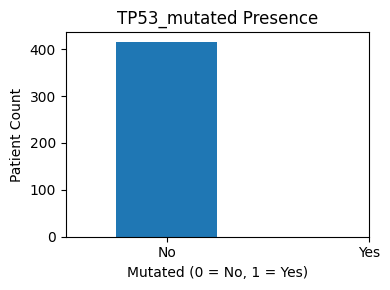

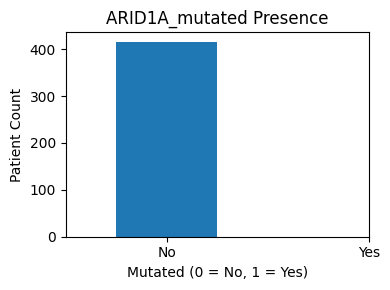

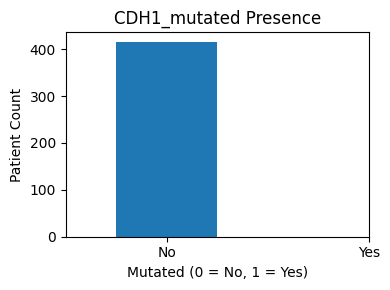

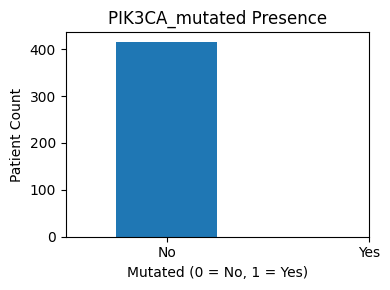

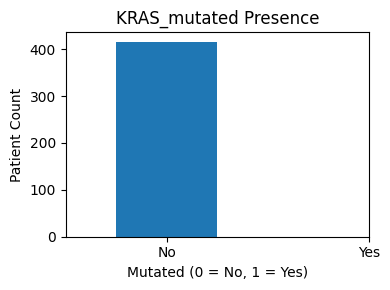

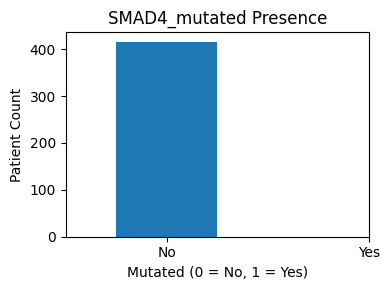

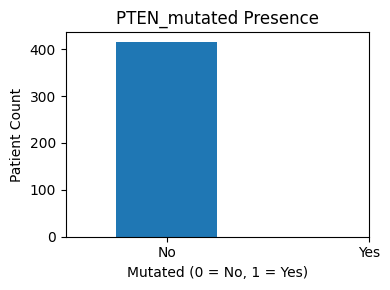

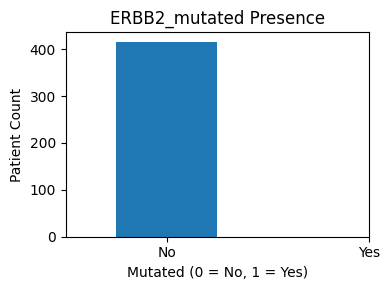

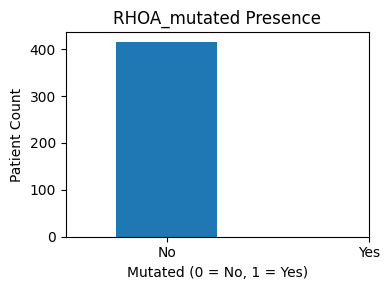

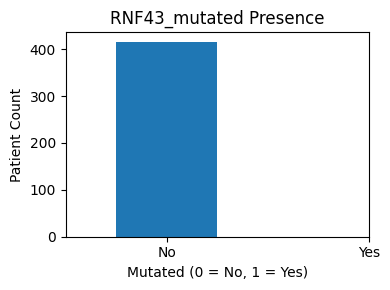

In [53]:
import matplotlib.pyplot as plt

# Plot mutation burden histogram
plt.figure(figsize=(6, 4))
X_final['mutation_burden'].hist(bins=30)
plt.title('Mutation Burden Distribution')
plt.xlabel('Number of Mutations')
plt.ylabel('Patient Count')
plt.show()

# Plot hypermutator status
plt.figure(figsize=(4, 3))
X_final['is_hypermutator'].value_counts().sort_index().plot(kind='bar')
plt.title('Hypermutator Status')
plt.xlabel('Hypermutator (0 = No, 1 = Yes)')
plt.ylabel('Patient Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.show()

# Plot histograms for driver gene mutations
driver_genes = [
    'TP53_mutated', 'ARID1A_mutated', 'CDH1_mutated', 'PIK3CA_mutated', 'KRAS_mutated',
    'SMAD4_mutated', 'PTEN_mutated', 'ERBB2_mutated', 'RHOA_mutated', 'RNF43_mutated'
]

for gene in driver_genes:
    plt.figure(figsize=(4, 3))
    X_final[gene].value_counts().sort_index().plot(kind='bar')
    plt.title(f'{gene} Presence')
    plt.xlabel('Mutated (0 = No, 1 = Yes)')
    plt.ylabel('Patient Count')
    plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
    plt.tight_layout()
    plt.show()


In [65]:
# List of mutation indicator columns
mutation_features = [col for col in X_final.columns if col.endswith('_mutated')]

# Key clinical features to keep
clinical_features = [
    'age_at_initial_pathologic_diagnosis',
    'gender',
    'tumor_status',
    'ajcc_pathologic_tumor_stage',
    'histological_grade'
]

# Combine features_fina
selected_cols = mutation_features + clinical_features + ['DSS']
df_reduced = X_final[selected_cols].copy()

# Drop rows with missing DSS
df_reduced = df_reduced[df_reduced['DSS'].notna()]

# One-hot encode categorical variables
df_reduced = pd.get_dummies(df_reduced, columns=['gender', 'tumor_status', 
                                                 'ajcc_pathologic_tumor_stage', 
                                                 'histological_grade'], drop_first=True)

print("✅ Final shape of reduced feature matrix:", df_reduced.shape)
df_reduced.head()



✅ Final shape of reduced feature matrix: (392, 30)


,TP53_mutated,ARID1A_mutated,CDH1_mutated,PIK3CA_mutated,KRAS_mutated,SMAD4_mutated,PTEN_mutated,ERBB2_mutated,RHOA_mutated,RNF43_mutated,...,ajcc_pathologic_tumor_stage_Stage III,ajcc_pathologic_tumor_stage_Stage IIIA,ajcc_pathologic_tumor_stage_Stage IIIB,ajcc_pathologic_tumor_stage_Stage IIIC,ajcc_pathologic_tumor_stage_Stage IV,ajcc_pathologic_tumor_stage_[Discrepancy],ajcc_pathologic_tumor_stage_[Not Available],histological_grade_G2,histological_grade_G3,histological_grade_GX
TCGA-CG-4460,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
TCGA-CG-5716,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
TCGA-HF-7131,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
TCGA-3M-AB46,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
TCGA-3M-AB47,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, accuracy_score)
import numpy as np

# ----------------------------
# Step 1: Split X and y
# ----------------------------
X = df_reduced.drop(columns='DSS')
y = df_reduced['DSS']

# ----------------------------
# Step 2: Handle missing values
# ----------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
print("✅ Shape after imputation:", X_imputed.shape)


# ----------------------------
# Step 3: Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=42
)

# ----------------------------
# Step 4: Train model
# ----------------------------
clf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# ----------------------------
# Step 5: Predictions and Evaluation
# ----------------------------
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

# ----------------------------
# Step 6: Print Results
# ----------------------------
print(f"🔍 AUC: {auc:.3f}")
print(f"🎯 Accuracy: {accuracy:.3f}")
print(f"🧪 Precision: {precision:.3f}")
print(f"📈 Recall (Sensitivity): {recall:.3f}")
print(f"📉 Specificity: {specificity:.3f}")
print(f"⚖️  F1 Score: {f1:.3f}")


✅ Shape after imputation: (392, 29)
🔍 AUC: 0.892
🎯 Accuracy: 0.886
🧪 Precision: 0.704
📈 Recall (Sensitivity): 0.950
📉 Specificity: 0.864
⚖️  F1 Score: 0.809
